In [1]:
import numpy as np
import matplotlib.pylab as plt

In [2]:
#D108 - day15 DKO
#D110 - day15 WT
#D118 - day0 WT

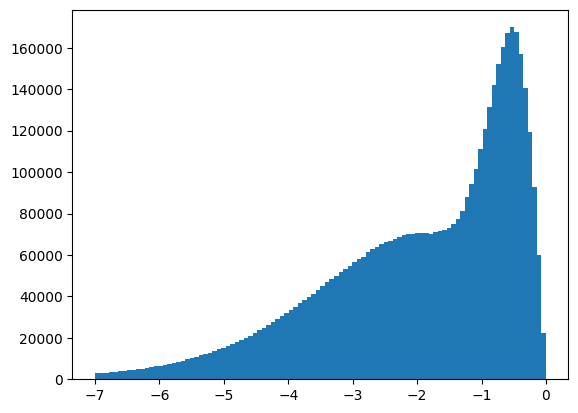

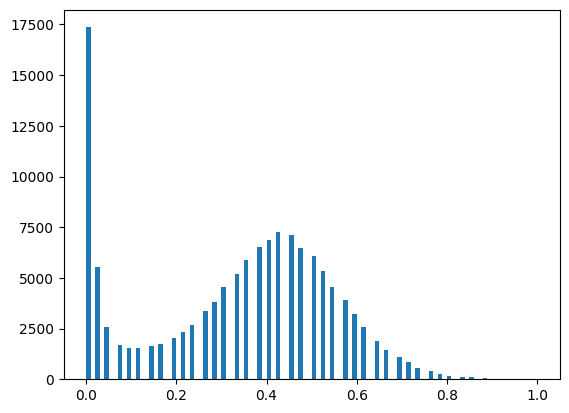

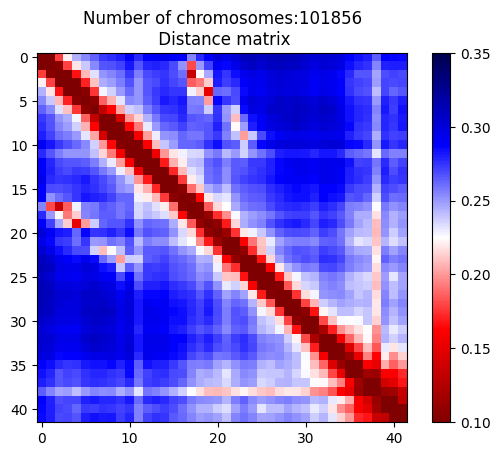

In [3]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D118_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-3]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D118 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

In [4]:
zxys_fs[:,0,-4]

array([0.54334996, 0.18035353, 0.43212088, ..., 0.32977779, 0.04941407,
       0.00268486])

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3216\734750626.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])


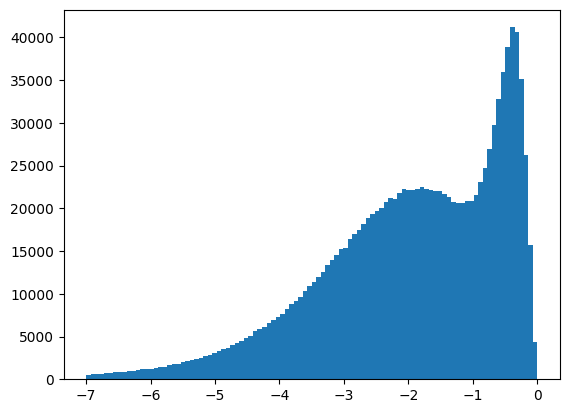

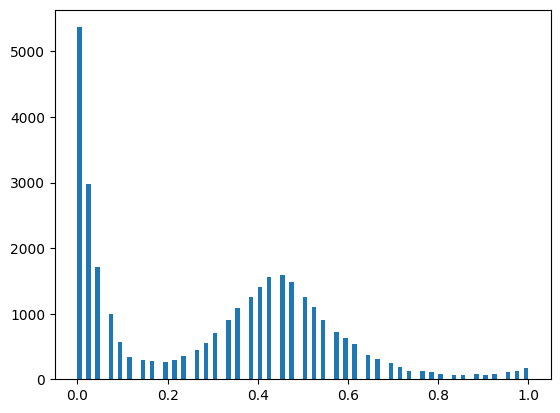

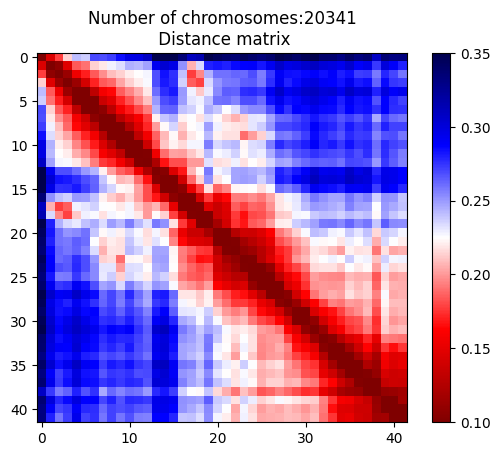

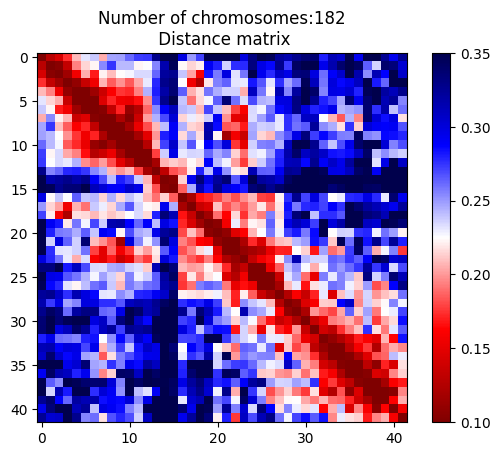

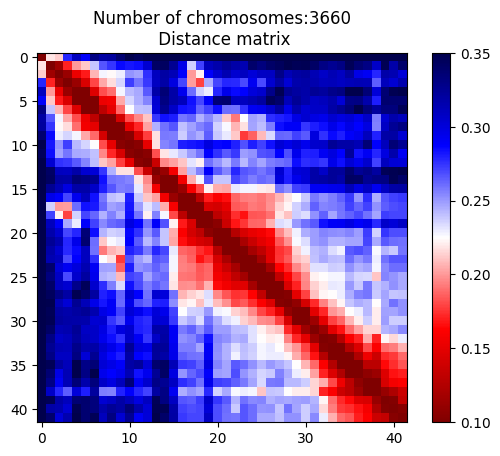

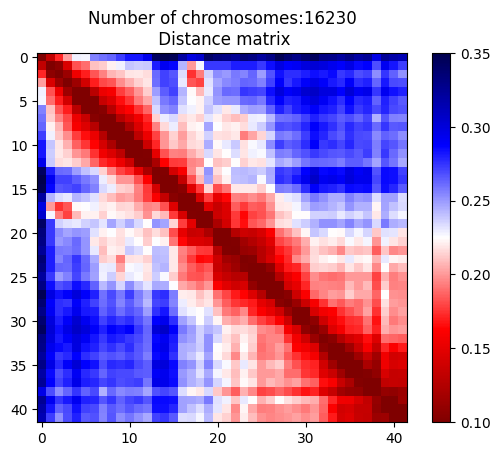

In [5]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D120_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1]=np.nan ######################################## Adjusting originally 1
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D120 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep6],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keepN],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

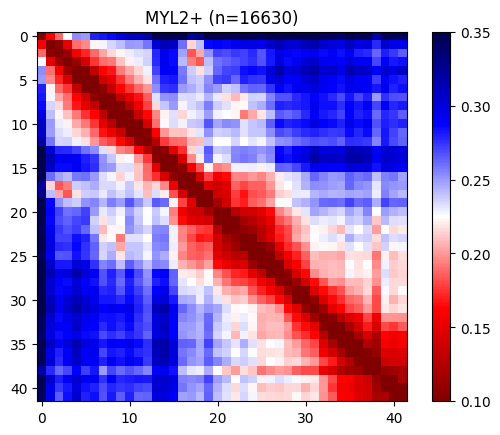

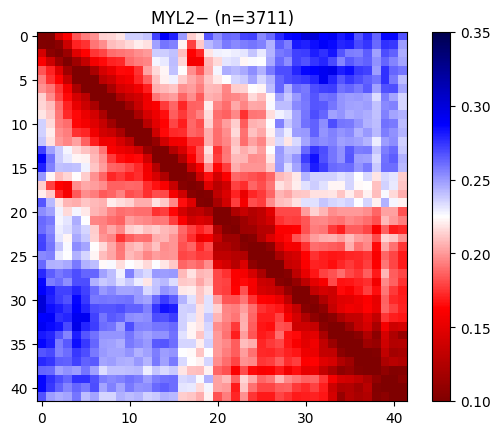

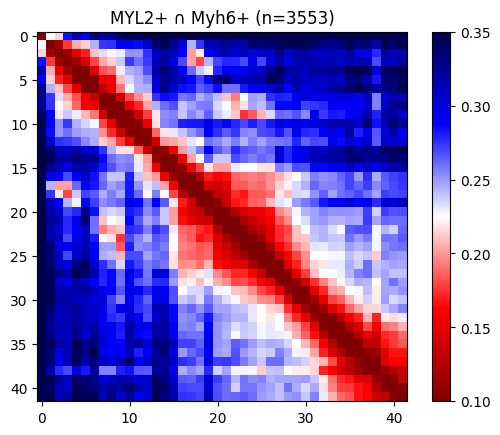

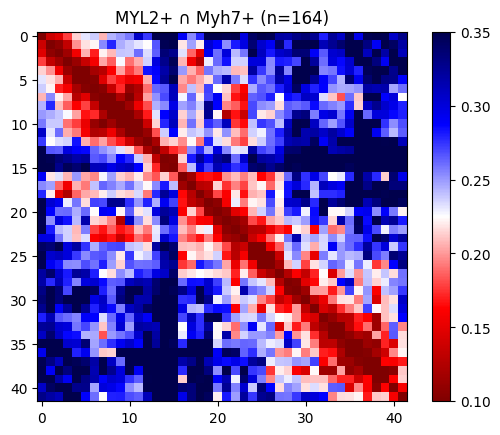

In [6]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# Step 2: Use already-defined H6, H7 and keep masks
# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D120_myl2     = mats_D120[keep_myl2]
mats_D120_nonmyl2  = mats_D120[keep_nonmyl2]
mats_D120_myl2_h6  = mats_D120[keep_myl2_myh6]
mats_D120_myl2_h7  = mats_D120[keep_myl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"MYL2+ (n={len(mats_D120_myl2)})")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2− (n={len(mats_D120_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh6+ (n={len(mats_D120_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh7+ (n={len(mats_D120_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

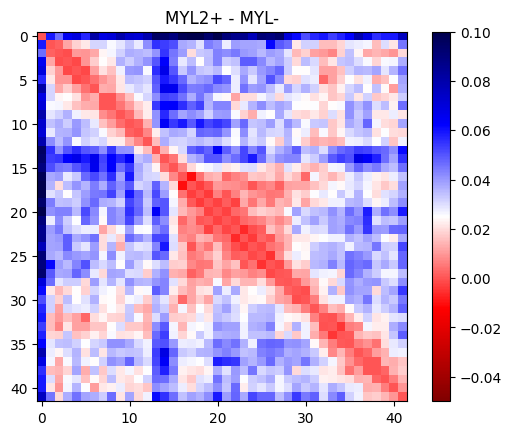

In [7]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0)-np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=-0.05, vmax=0.1)
plt.colorbar()

In [8]:
med_D120 = np.nanmedian(mats_D120,axis=0)


C:\Users\Carlos\AppData\Local\Temp\ipykernel_3216\3671604749.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])


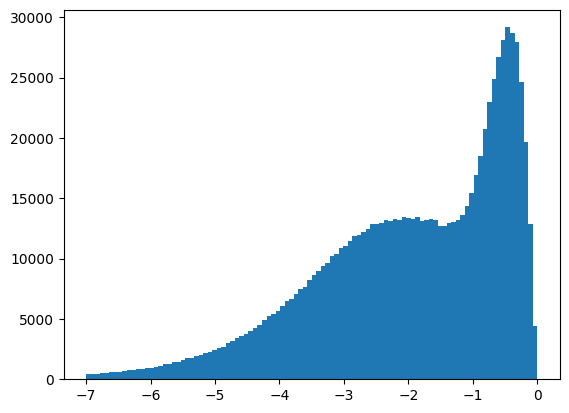

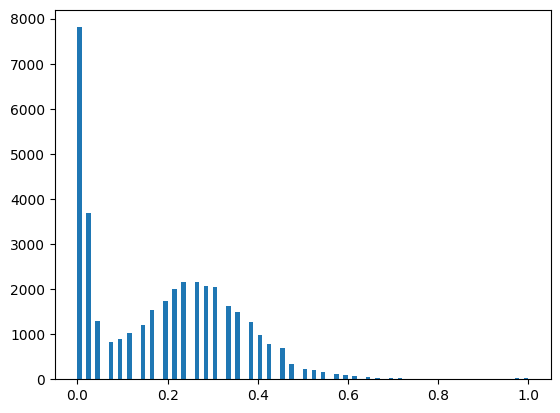

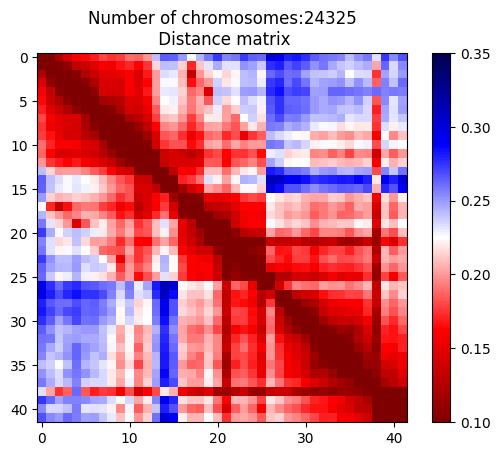

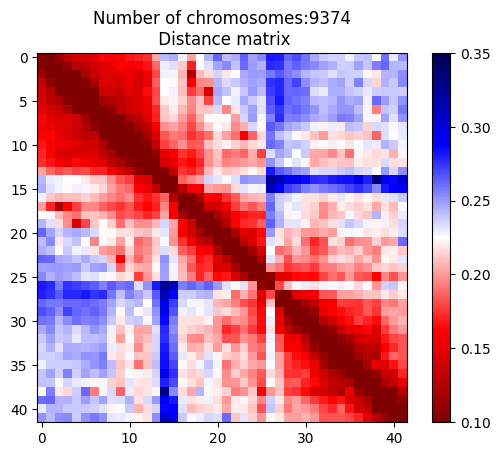

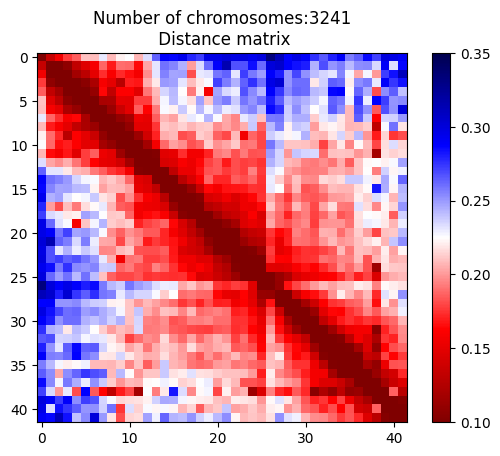

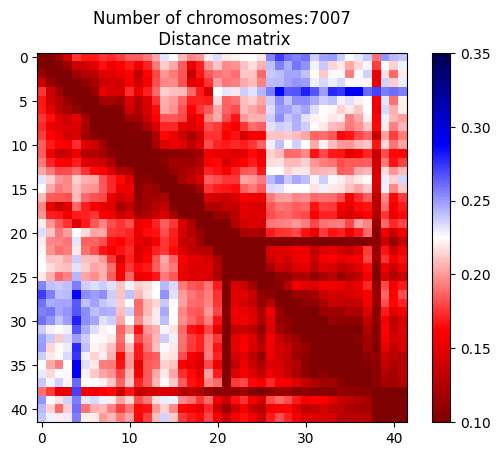

In [9]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D104_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D104 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep6],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keepN],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

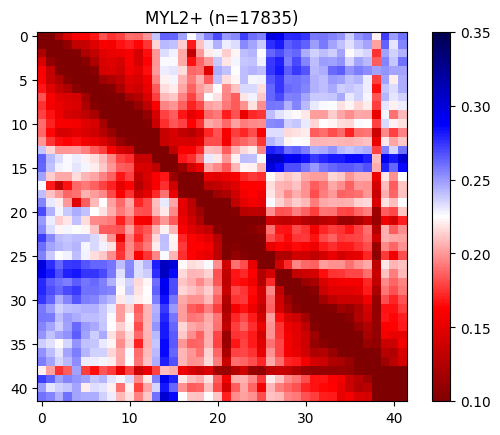

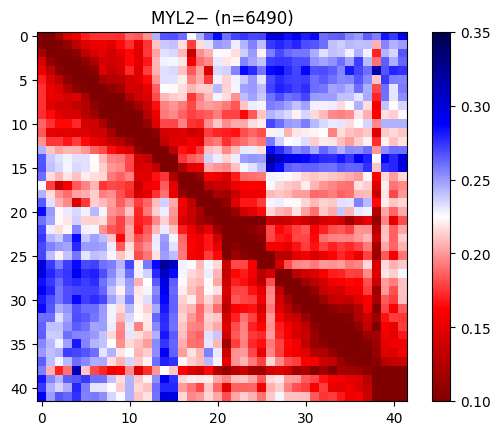

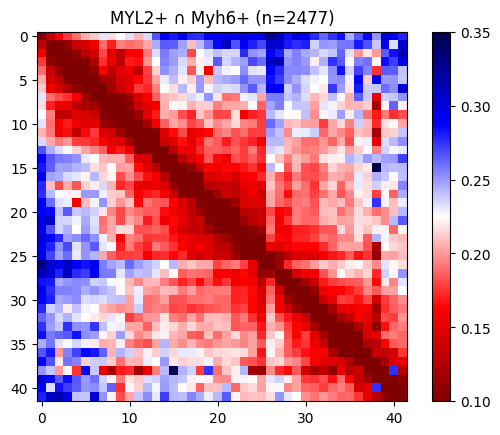

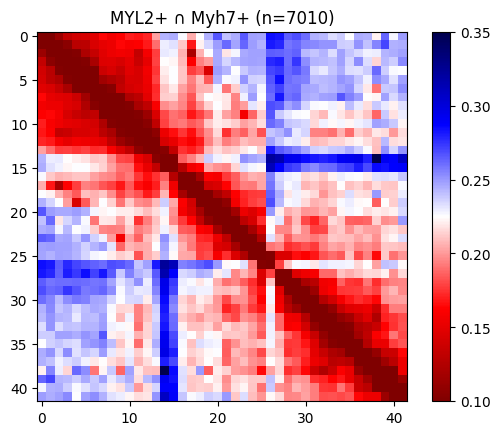

In [10]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# Step 2: Use already-defined H6, H7 and keep masks
# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D104_myl2     = mats_D104[keep_myl2]
mats_D104_nonmyl2  = mats_D104[keep_nonmyl2]
mats_D104_myl2_h6  = mats_D104[keep_myl2_myh6]
mats_D104_myl2_h7  = mats_D104[keep_myl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"MYL2+ (n={len(mats_D104_myl2)})")
plt.imshow(np.nanmedian(mats_D104_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2− (n={len(mats_D104_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh6+ (n={len(mats_D104_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh7+ (n={len(mats_D104_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

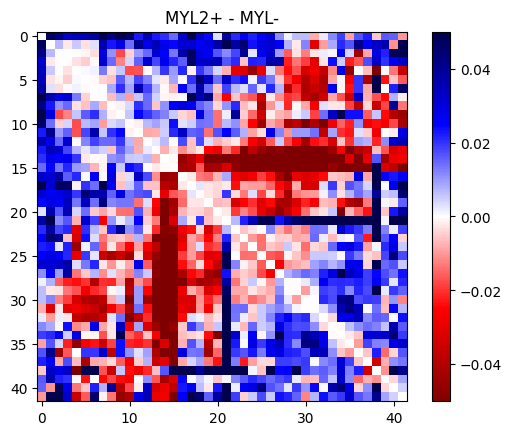

In [11]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D104_myl2_h6, axis=0)-np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r', vmin=-0.05, vmax=0.05)
plt.colorbar()

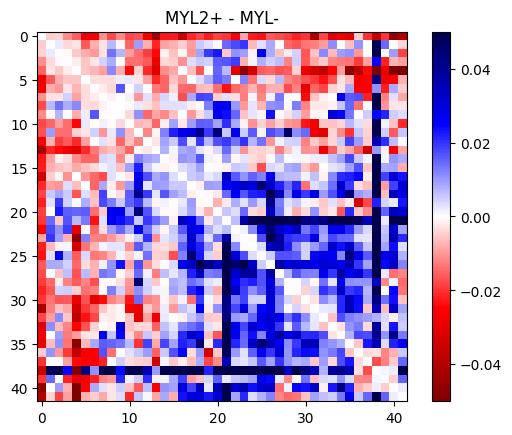

In [12]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D104_myl2_h7, axis=0)-np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r', vmin=-0.05, vmax=0.05)
plt.colorbar()

In [13]:

med_D104 = np.nanmedian(mats_D104,axis=0)
med_D118 = np.nanmedian(mats_D118,axis=0)
med_D104_keep7 = np.nanmedian(mats_D104[keep7],axis=0)
med_D104_keep6 = np.nanmedian(mats_D104[keep6],axis=0)
med_D104_keepN = np.nanmedian(mats_D104[keepN],axis=0)

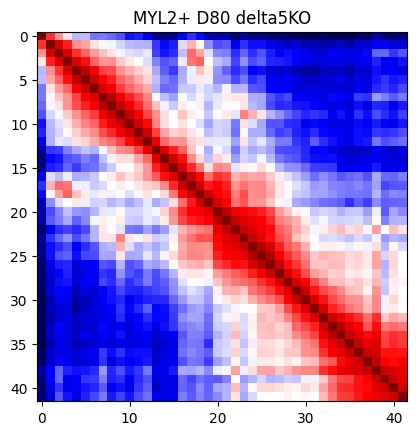

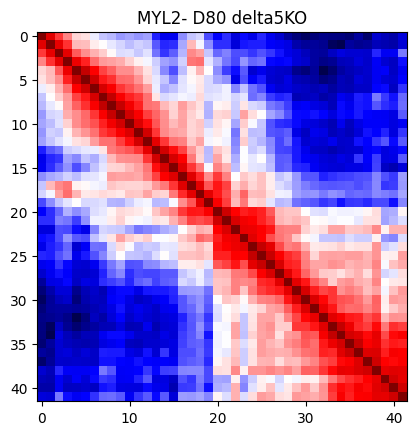

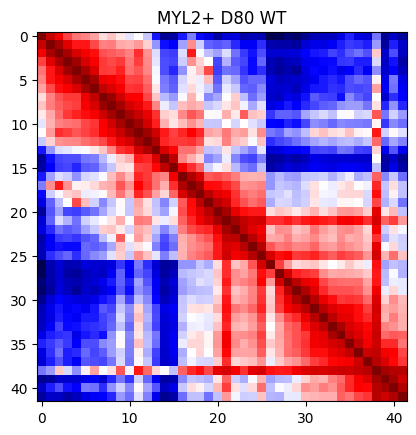

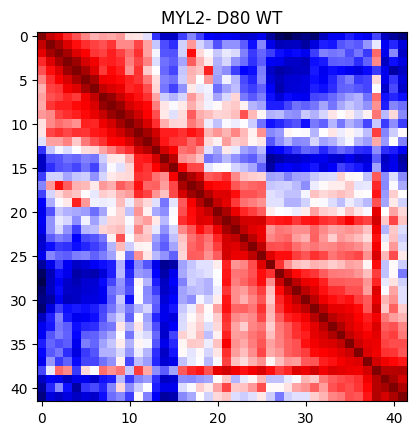

In [14]:
dth = 0.15

plt.figure()
plt.title(f"MYL2+ D80 delta5KO")
mat_delta_myl2 = np.sum(mats_D120_myl2[:]<dth,axis=0)/np.sum(mats_D120_myl2[:]>=0,axis=0)
plt.imshow(np.log(mat_delta_myl2),cmap='seismic')

plt.figure()
plt.title(f"MYL2- D80 delta5KO")
mat_delta_nonmyl2 = np.sum(mats_D120_nonmyl2[:]<dth,axis=0)/np.sum(mats_D120_nonmyl2[:]>=0,axis=0)
plt.imshow(np.log(mat_delta_nonmyl2),cmap='seismic')

plt.figure()
plt.title(f"MYL2+ D80 WT")
mat_wt_myl2 = np.sum(mats_D104_myl2[:]<dth,axis=0)/np.sum(mats_D104_myl2[:]>=0,axis=0)
plt.imshow(np.log(mat_wt_myl2),cmap='seismic')

plt.figure()
plt.title(f"MYL2- D80 WT")
mat_wt_nonmyl2 = np.sum(mats_D104_nonmyl2[:]<dth,axis=0)/np.sum(mats_D104_nonmyl2[:]>=0,axis=0)
plt.imshow(np.log(mat_wt_nonmyl2),cmap='seismic')

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3216\3242135292.py:1: RuntimeWarning: invalid value encountered in divide
  plt.imshow(np.log(mat_delta_myl2)/np.log(mat_delta_nonmyl2),cmap='seismic', vmin=1, vmax = 1.5)


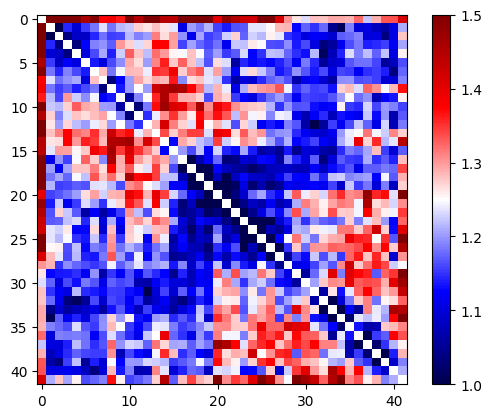

In [15]:
plt.imshow(np.log(mat_delta_myl2)/np.log(mat_delta_nonmyl2),cmap='seismic', vmin=1, vmax = 1.5)
plt.colorbar()

In [7]:
data = [med_D120_keep.ravel()/med_D104_keep7.ravel(),med_D120_keep.ravel()/med_D104_keep6.ravel(),med_D120_keep.ravel()/med_D104_keepN.ravel(),med_D120_keep.ravel()/med_D118.ravel()]
data = [d[~np.isnan(d)]for d in data]

C:\Users\Carlos\AppData\Local\Temp\ipykernel_15760\3297490314.py:1: RuntimeWarning: invalid value encountered in divide
  data = [med_D120.ravel()/med_D104_keep7.ravel(),med_D120.ravel()/med_D104_keep6.ravel(),med_D120.ravel()/med_D104_keepN.ravel(),med_D120.ravel()/med_D118.ravel()]


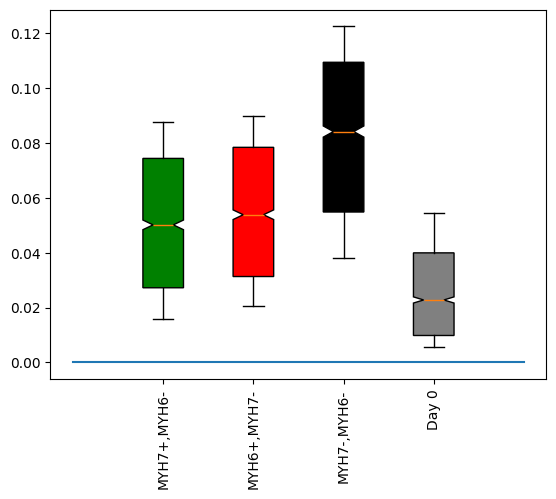

In [10]:
data = np.abs([med_D120_keep.ravel()-med_D104_keep7.ravel(),med_D120_keep.ravel()-med_D104_keep6.ravel(),med_D120_keep.ravel()-med_D104_keepN.ravel(),med_D120_keep.ravel()-med_D118.ravel()])
data = [d[~np.isnan(d)]for d in data]
bp = plt.boxplot([d for d in data], patch_artist=True, showfliers=False,whis=[15,85],notch=True,)

# Define the colors for each box
colors = ['green','red', 'black', 'gray']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.plot([0,5],[0,0])
plt.xticks(np.arange(4)+1,['MYH7+,MYH6-','MYH6+,MYH7-','MYH7-,MYH6-','Day 0'],rotation='vertical');

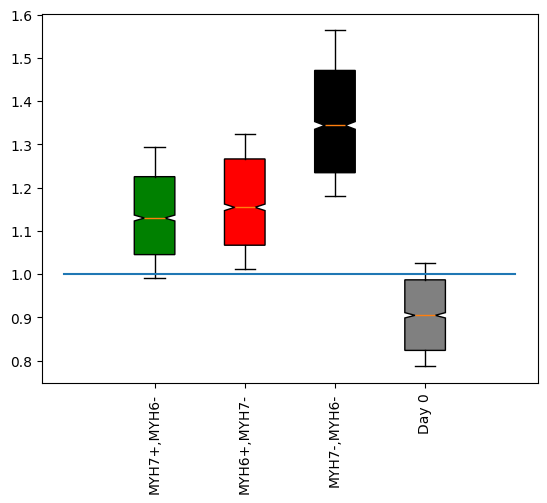

In [8]:
bp = plt.boxplot([d for d in data], patch_artist=True, showfliers=False,whis=[15,85],notch=True,)

# Define the colors for each box
colors = ['green','red', 'black', 'gray']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.plot([0,5],[1,1])
plt.xticks(np.arange(4)+1,['MYH7+,MYH6-','MYH6+,MYH7-','MYH7-,MYH6-','Day 0'],rotation='vertical');

In [ ]:
# Step 4: Compute matrices
mats_D120_myl2     = mats_D120[keep_myl2]
mats_D120_nonmyl2  = mats_D120[keep_nonmyl2]
mats_D120_myl2_h6  = mats_D120[keep_myl2_myh6]
mats_D120_myl2_h7  = mats_D120[keep_myl2_myh7]

# Step 4: Compute matrices
mats_D104_myl2     = mats_D104[keep_myl2]
mats_D104_nonmyl2  = mats_D104[keep_nonmyl2]
mats_D104_myl2_h6  = mats_D104[keep_myl2_myh6]
mats_D104_myl2_h7  = mats_D104[keep_myl2_myh7]

In [16]:
def get_random_maps(mats,iDNA7_,N=100,dth=0.1):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        iRand = np.random.randint(0,len(iDNA7_),len(iDNA7_))
        med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [17]:
def get_random_maps_log(mats,iDNA7_,N=100,dth=0.15):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        iRand = np.random.randint(0,len(iDNA7_),len(iDNA7_))
        med_7_C = np.log(np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0))
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [18]:
from tqdm import tqdm
# mats_D103_7 = get_random_maps(mats_D103,np.where(keep7)[0],N=100,dth=0.1)
# mats_D103_6 = get_random_maps(mats_D103,np.where(keep6)[0],N=100,dth=0.1)

mats_D120_p = get_random_maps(mats_D120_myl2,np.arange(len(mats_D120_myl2)),N=100,dth=0.1)
mats_D120_m = get_random_maps(mats_D120_nonmyl2,np.arange(len(mats_D120_nonmyl2)),N=100,dth=0.1)
mats_D104_p = get_random_maps(mats_D104_myl2,np.arange(len(mats_D104_myl2)),N=100,dth=0.1)
mats_D104_m = get_random_maps(mats_D104_nonmyl2,np.arange(len(mats_D104_nonmyl2)),N=100,dth=0.1)
mats_D118_all = get_random_maps(mats_D118,np.arange(len(mats_D118)),N=100,dth=0.1)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:28<00:00,  1.13it/s]


In [19]:
from tqdm import tqdm
# mats_D103_7 = get_random_maps(mats_D103,np.where(keep7)[0],N=100,dth=0.1)
# mats_D103_6 = get_random_maps(mats_D103,np.where(keep6)[0],N=100,dth=0.1)

mats_D120_p_h6 = get_random_maps(mats_D120_myl2_h6,np.arange(len(mats_D120_myl2_h6)),N=100,dth=0.1)
mats_D120_p_h7 = get_random_maps(mats_D120_myl2_h7,np.arange(len(mats_D120_myl2_h7)),N=100,dth=0.1)
mats_D104_p_h6 = get_random_maps(mats_D104_myl2_h6,np.arange(len(mats_D104_myl2_h6)),N=100,dth=0.1)
mats_D104_p_h7 = get_random_maps(mats_D104_myl2_h7,np.arange(len(mats_D104_myl2_h7)),N=100,dth=0.1)

  0%|                                                                                          | 0/100 [00:00<?, ?it/s]C:\Users\Carlos\AppData\Local\Temp\ipykernel_3216\945849956.py:5: RuntimeWarning: invalid value encountered in divide
  med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 16.76it/s]


In [21]:
X, Z = [], []

for i in range(27):
    i1,i2 = i, i+15
    
    X.append(mats_D120_p[:,i1,i2].mean())
    
    Z.append(mats_D104_p[:,i1,i2].mean())
    

In [27]:
mats_D120_p[:,i1,i2].mean()

0.0719348234182595

In [26]:
X

[0.038740698629132986,
 0.11683149222178052,
 0.23519037300492884,
 0.26712050078055766,
 0.15495162081473368,
 0.09776076121971887,
 0.12956133462663952,
 0.15362713274818587,
 0.15192817107666048,
 0.18396102165887793,
 0.10627888573332708,
 0.0749251060895166,
 0.0778302133432033,
 0.0719348234182595,
 0.07390198576776051,
 0.0779113855158918,
 0.07733721522663385,
 0.08662877714325617,
 0.08667857867555005,
 0.06564775683666245,
 0.09508758013315065,
 0.12191919857355404,
 0.1411529525681707,
 0.10561832406143729,
 0.09325238592643183,
 0.1326682884172199,
 0.1215246577585849]

In [29]:
mats_D104_p[:,i1,i2].mean()

0.08570562329050896

In [30]:
Z

[0.05795473599064534,
 0.1455473126783419,
 0.3602004271347978,
 0.22332263317508672,
 0.3050649131222814,
 0.12277904449492921,
 0.16903326021201848,
 0.22463723525424456,
 0.18326809900833888,
 0.18829313282322593,
 0.13347979669545681,
 0.12173664838945399,
 0.10184441091695635,
 0.08570562329050896,
 0.06426197873679035,
 0.07640234207329354,
 0.15060314890686186,
 0.16583393180246062,
 0.173468575799329,
 0.23006920069966155,
 0.29215535357117167,
 0.4312523479888836,
 0.23686649301983728,
 0.37763957679135224,
 0.16570043391692357,
 0.28359028993368157,
 0.14811130171848813]

In [25]:
i1,i2 = [13,28]

mats_D120_p[:,i1,i2].mean()/np.mean(X), mats_D104_p[:,i1,i2].mean()/np.mean(Z)

(0.6185535137084993, 0.44340499040109066)

In [47]:
X, Z = [], []

for i in range(24):
    i1,i2 = i, i+18
    
    X.append(mats_D120_p[:,i1,i2].mean())
    
    Z.append(mats_D104_p[:,i1,i2].mean())

In [48]:
i1,i2 = [13,31]

mats_D120_p[:,i1,i2].mean()/np.mean(X), mats_D104_p[:,i1,i2].mean()/np.mean(Z)

(0.752258173567542, 0.7404326485260107)

In [42]:
X, Z = [], []

for i in range(38):
    i1,i2 = i, i+4
    
    X.append(mats_D120_p[:,i1,i2].mean())
    
    Z.append(mats_D104_p[:,i1,i2].mean())

In [43]:
i1,i2 = [27,31]

mats_D120_p[:,i1,i2].mean()/np.mean(X), mats_D104_p[:,i1,i2].mean()/np.mean(Z)

(0.8454711862199811, 1.01987954227123)

In [20]:
mats_D120_p[:,i1,i2]

array([0.17368929, 0.17506545, 0.17385642, 0.16790803, 0.17500402,
       0.17665155, 0.16375199, 0.1697837 , 0.17779194, 0.17608731,
       0.17377261, 0.16099071, 0.16841595, 0.17089431, 0.16608056,
       0.17798106, 0.17309257, 0.17560429, 0.17891997, 0.16829151,
       0.17449341, 0.1791795 , 0.1745903 , 0.16319159, 0.17217899,
       0.18601647, 0.1687852 , 0.1677776 , 0.17354173, 0.1686572 ,
       0.17411651, 0.17686628, 0.16682832, 0.17247442, 0.17336321,
       0.17514582, 0.17163212, 0.17455669, 0.16557805, 0.17764631,
       0.1756713 , 0.18158649, 0.16322281, 0.17305195, 0.17232665,
       0.17255651, 0.17535854, 0.17192301, 0.16796875, 0.17751672,
       0.17195082, 0.17380721, 0.16842276, 0.1763285 , 0.16685827,
       0.17075163, 0.16787498, 0.17077954, 0.1755102 , 0.17404704,
       0.16898673, 0.16987797, 0.16510197, 0.17586946, 0.16973126,
       0.16661206, 0.17126016, 0.1686457 , 0.16625717, 0.17272006,
       0.17288676, 0.17435656, 0.17353369, 0.17687185, 0.17650

Text(0, 0.5, 'Contact frequency')

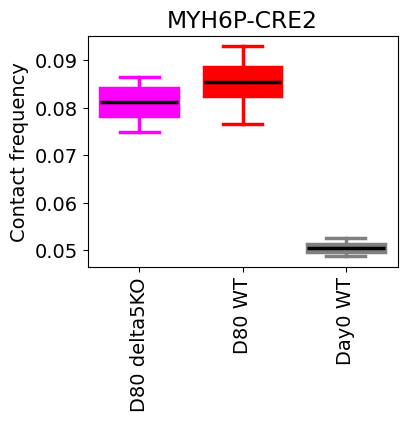

In [20]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

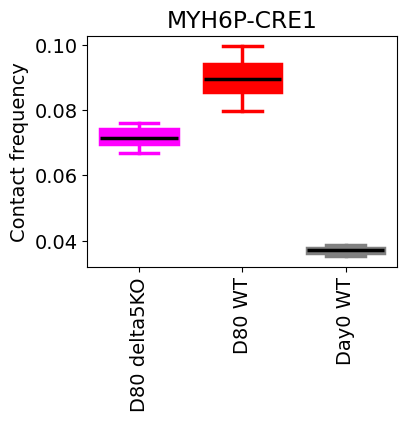

In [21]:
i1,i2 = [13,30]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

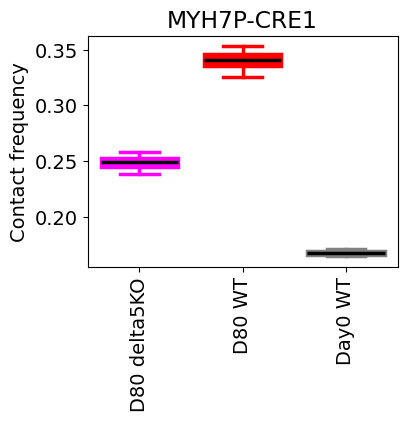

In [22]:
i1,i2 = [27,30]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

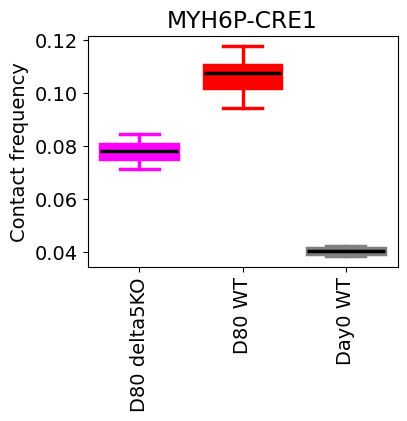

In [38]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

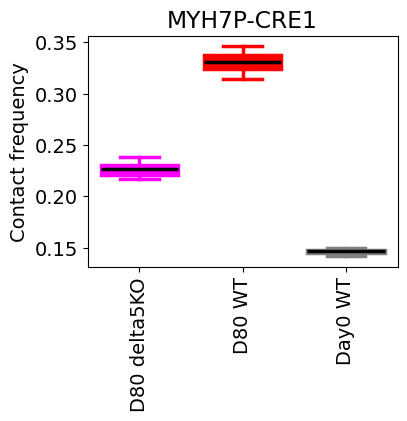

In [39]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

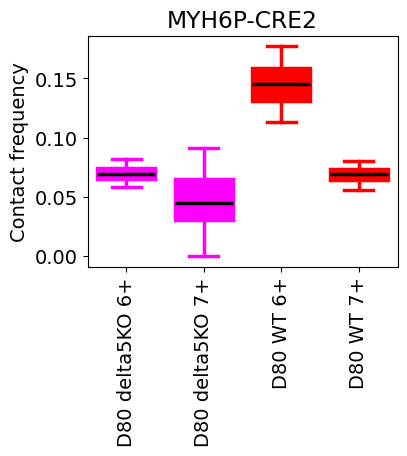

In [84]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p_h6[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D120_p_h7[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Y = mats_D104_p_h7[:,i1,i2]
box_Y = ax.boxplot(Y, positions=[0.6], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.7])
plt.xticks([0,0.2,0.4, 0.6],['D80 delta5KO 6+', 'D80 delta5KO 7+','D80 WT 6+','D80 WT 7+'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

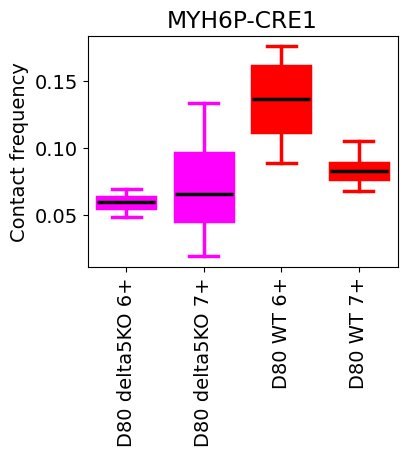

In [85]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p_h6[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D120_p_h7[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Y = mats_D104_p_h7[:,i1,i2]
box_Y = ax.boxplot(Y, positions=[0.6], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.7])
plt.xticks([0,0.2,0.4, 0.6],['D80 delta5KO 6+', 'D80 delta5KO 7+','D80 WT 6+','D80 WT 7+'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

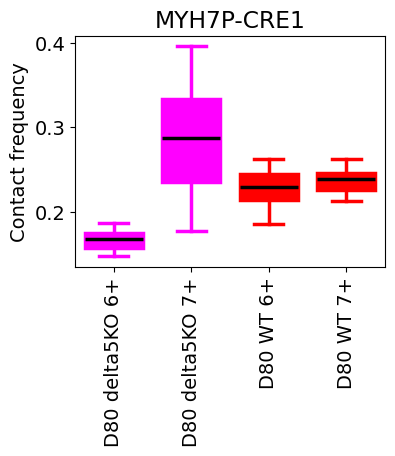

In [86]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p_h6[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D120_p_h7[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Y = mats_D104_p_h7[:,i1,i2]
box_Y = ax.boxplot(Y, positions=[0.6], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.7])
plt.xticks([0,0.2,0.4, 0.6],['D80 delta5KO 6+', 'D80 delta5KO 7+','D80 WT 6+','D80 WT 7+'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\2085552967.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = (mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

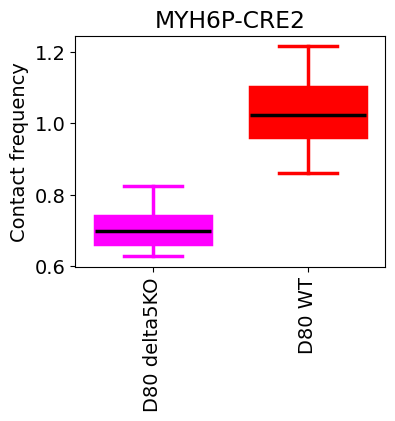

In [80]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = (mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = (mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 delta5KO','D80 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\3537173388.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = np.log(mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

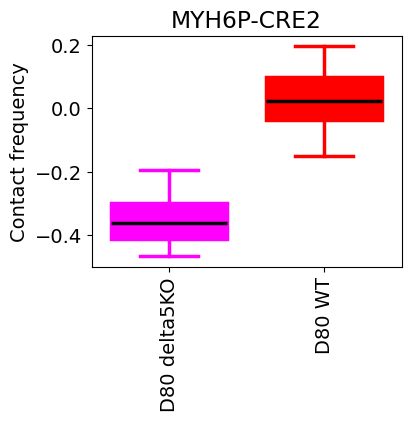

In [79]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = np.log(mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = np.log(mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D80 delta5KO','D80 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\3150344836.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = (mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

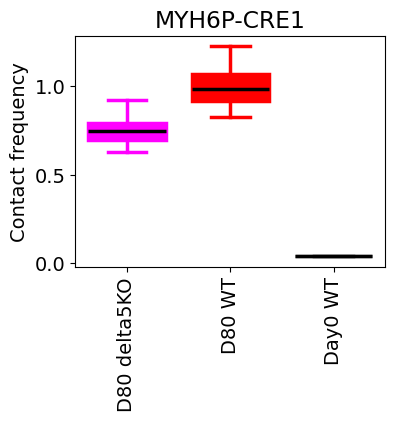

In [70]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = (mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = (mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\130861578.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = (mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

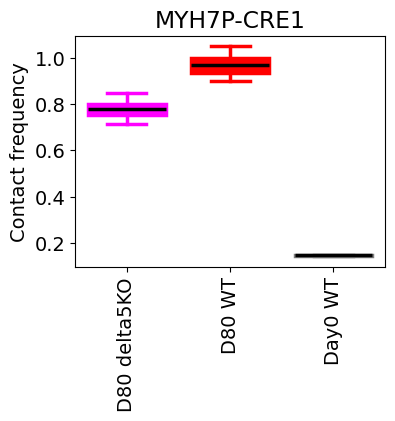

In [72]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = (mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = (mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

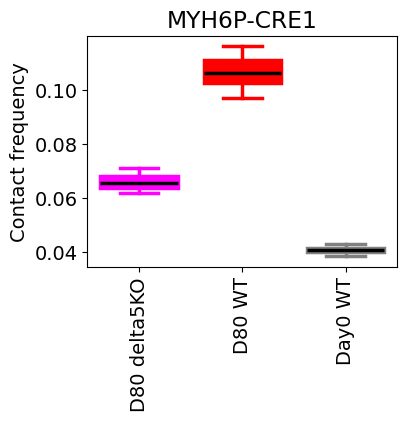

In [18]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

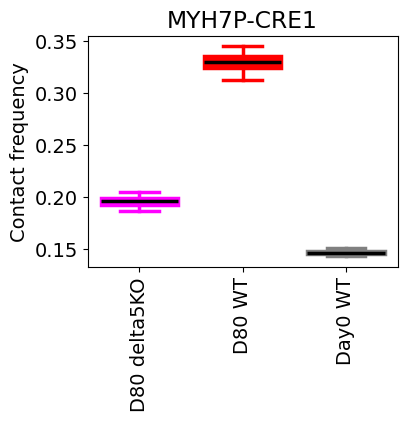

In [19]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))
# X = mats_D103_6[:,i1,i2]
# box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
#                    boxprops=dict(facecolor='red', color='red',linewidth=line_width),
#                    whiskerprops=dict(color='red',linewidth=line_width),
#                    capprops=dict(color='red',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# # Box plot for Y in green
# Y = mats_D103_7[:,i1,i2]
# box_Y = ax.boxplot(Y, positions=[0.2], patch_artist=True, 
#                    boxprops=dict(facecolor='green', color='green',linewidth=line_width),
#                    whiskerprops=dict(color='green',linewidth=line_width),
#                    capprops=dict(color='green',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

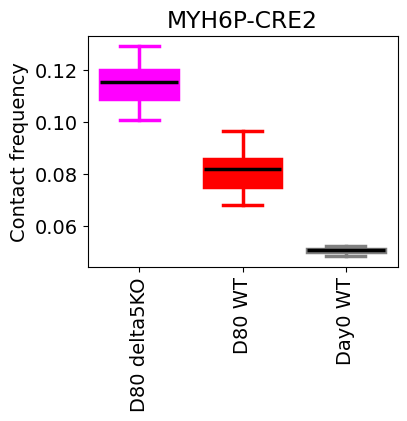

In [20]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

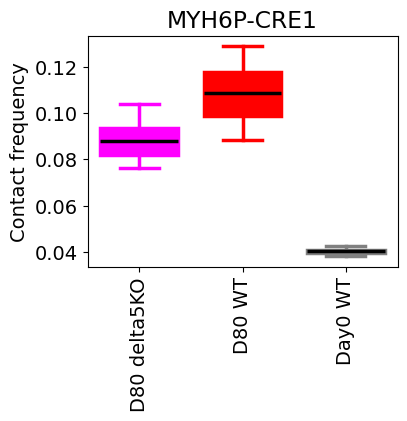

In [21]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

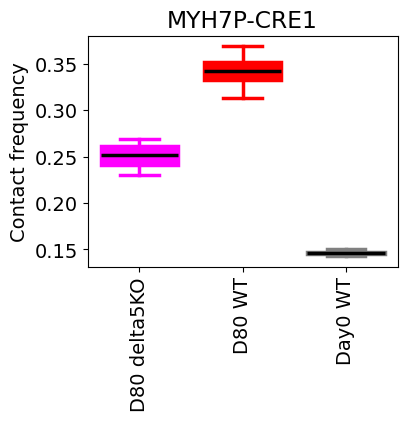

In [22]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")